<a href="https://colab.research.google.com/github/Abhinavharle45-hub/pagu-infobyte/blob/main/Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TASK 2: Customer Segmentation Analysis

**Objective:** Apply clustering algorithms to segment an e-commerce company's customer base into distinct groups based on purchasing behaviour, enabling targeted marketing strategies.

**Tech Stack:** Python, pandas, scikit-learn (KMeans), matplotlib, seaborn, Jupyter Notebook

## 1. Setup: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set(style="whitegrid")
%matplotlib inline

print("Libraries loaded successfully")

Libraries loaded successfully


## 2. Load Dataset

**Google Colab:** run the upload cell below and select `ecommerce_customer_data.csv`.
**Local Jupyter:** skip the upload cell — just make sure the CSV is in the same folder as this notebook.

In [2]:
# Run this cell ONLY if you're in Google Colab
from google.colab import files
uploaded = files.upload()

csv_filename = list(uploaded.keys())[0]
print("Uploaded file name:", csv_filename)

Saving ecommerce_customer_data.csv to ecommerce_customer_data.csv
Uploaded file name: ecommerce_customer_data.csv


In [3]:
try:
    df = pd.read_csv(csv_filename)
except NameError:
    df = pd.read_csv("ecommerce_customer_data.csv")

print("Dataset loaded. Shape:", df.shape)
df.head()

Dataset loaded. Shape: (7009, 7)


,InvoiceNo,InvoiceDate,CustomerID,Description,Quantity,UnitPrice,Country
0,536693,2024-01-01,1049.0,Face Cream,3,18.40,Germany
1,537829,2024-01-01,1200.0,Phone Case,4,9.88,USA
2,539147,2024-01-01,1343.0,Wireless Mouse,1,19.15,USA
3,537062,2024-01-01,1102.0,Water Bottle,3,8.26,France
4,537694,2024-01-01,1182.0,Travel Mug,2,11.31,United Kingdom


## 3. Inspect Structure, Handle Missing Values & Inconsistent Data

In [4]:
print("Shape:", df.shape)
df.info()
print("\nMissing values:")
print(df.isnull().sum())

Shape: (7009, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7009 entries, 0 to 7008
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    7009 non-null   int64  
 1   InvoiceDate  7009 non-null   object 
 2   CustomerID   6989 non-null   float64
 3   Description  7009 non-null   object 
 4   Quantity     7009 non-null   int64  
 5   UnitPrice    7009 non-null   float64
 6   Country      7009 non-null   object 
dtypes: float64(2), int64(2), object(3)
memory usage: 383.4+ KB

Missing values:
InvoiceNo       0
InvoiceDate     0
CustomerID     20
Description     0
Quantity        0
UnitPrice       0
Country         0
dtype: int64


In [5]:
# Drop rows with no CustomerID - can't attribute these to any customer
df = df.dropna(subset=['CustomerID'])

# Remove returns / cancellations (negative quantity) and invalid prices
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

# Remove duplicate rows
df = df.drop_duplicates()

df['CustomerID'] = df['CustomerID'].astype(int)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("Shape after cleaning:", df.shape)

Shape after cleaning: (6964, 7)


**Observation:** *(how many rows had missing CustomerID, how many were returns/negative quantity, how many duplicates removed)*

## 4. Descriptive Statistics

In [6]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

avg_purchase_value = df.groupby('CustomerID')['TotalPrice'].mean()
purchase_frequency = df.groupby('CustomerID')['InvoiceNo'].nunique()
clv = df.groupby('CustomerID')['TotalPrice'].sum()

print("Average purchase value per customer: $%.2f" % avg_purchase_value.mean())
print("Average purchase frequency (orders/customer): %.2f" % purchase_frequency.mean())
print("Average Customer Lifetime Value: $%.2f" % clv.mean())

Average purchase value per customer: $74.51
Average purchase frequency (orders/customer): 8.04
Average Customer Lifetime Value: $1466.56


**Observation:** *(comment on the spread — are most customers low-value with a few high spenders?)*

## 5. Feature Selection: RFM Analysis (Recency, Frequency, Monetary)

In [7]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']

print("RFM table shape:", rfm.shape)
rfm.head()

RFM table shape: (350, 3)


,Recency,Frequency,Monetary
CustomerID,,,
1000,4,24,4208.84
1001,23,1,329.16
1002,224,2,139.57
1003,75,5,823.96
1004,27,2,423.48


**Observation:** *(why these 3 features make sense for segmentation — recency = engagement, frequency = loyalty, monetary = value)*

## 6. Standardise Features Before Clustering

In [8]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

print("Scaled feature means (should be ~0):", rfm_scaled.mean(axis=0).round(2))
print("Scaled feature stds (should be ~1):", rfm_scaled.std(axis=0).round(2))

Scaled feature means (should be ~0): [0. 0. 0.]
Scaled feature stds (should be ~1): [1. 1. 1.]


## 7. K-Means Clustering: Elbow Method

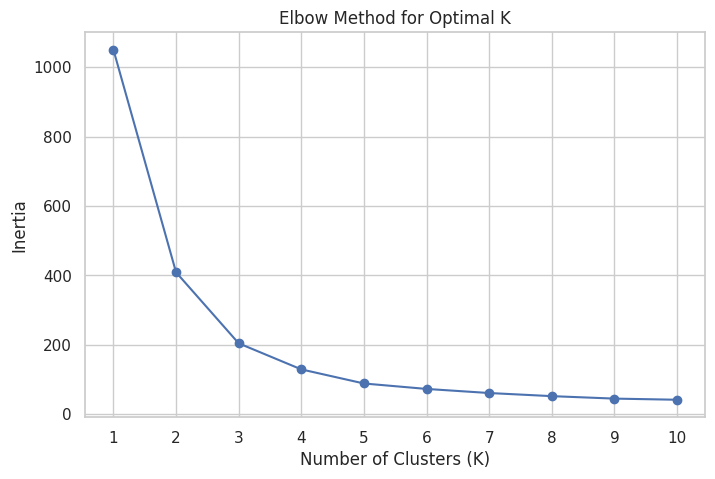

In [9]:
inertia = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.xticks(list(K_range))
plt.show()

**Observation:** *(state which K you're choosing based on where the curve bends, e.g. "the elbow appears around K=4")*

## 8. Apply K-Means with Chosen K

In [10]:
optimal_k = 4  # <-- update this based on your elbow chart

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
1000,4,24,4208.84,2
1001,23,1,329.16,0
1002,224,2,139.57,3
1003,75,5,823.96,1
1004,27,2,423.48,0


## 9. Visualise Clusters

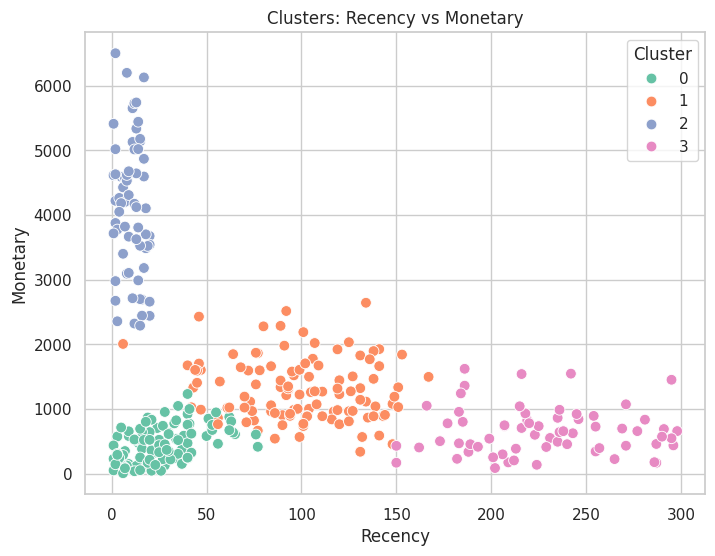

In [11]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Recency', y='Monetary', hue='Cluster', data=rfm, palette='Set2', s=60)
plt.title("Clusters: Recency vs Monetary")
plt.show()

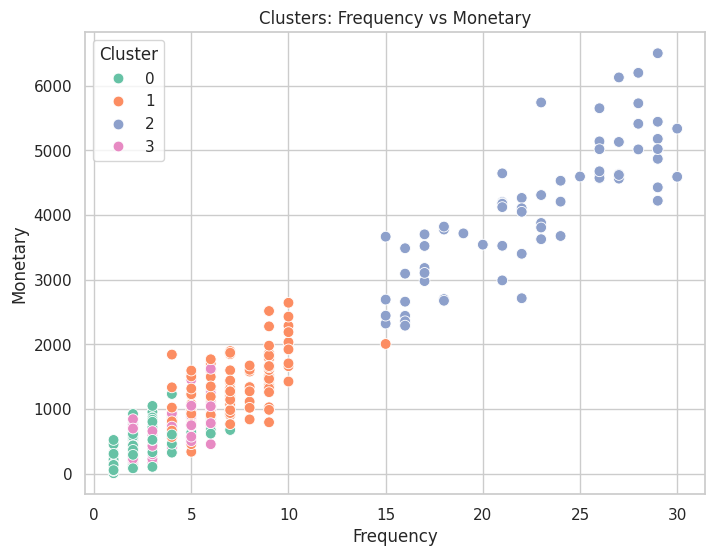

In [12]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Frequency', y='Monetary', hue='Cluster', data=rfm, palette='Set2', s=60)
plt.title("Clusters: Frequency vs Monetary")
plt.show()

## 10. Profile Each Cluster

In [13]:
cluster_profile = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().round(2)
cluster_profile['CustomerCount'] = rfm.groupby('Cluster').size()
cluster_profile

,Recency,Frequency,Monetary,CustomerCount
Cluster,,,,
0,27.09,2.58,454.32,104
1,99.24,6.92,1299.39,113
2,10.31,22.58,4123.25,67
3,227.20,3.80,650.90,66


**Describe each cluster in plain English**, e.g.:
- Cluster 0: low recency, high frequency, high monetary → **loyal high-value customers**
- Cluster 1: high recency, low frequency, low monetary → **at-risk / churned customers**
- Cluster 2: low recency, low frequency, moderate monetary → **new customers**
- Cluster 3: moderate on all three → **occasional shoppers**

*(Replace with your actual cluster numbers and values once you run the cell above)*

## 11. Bar Chart: Customers per Cluster

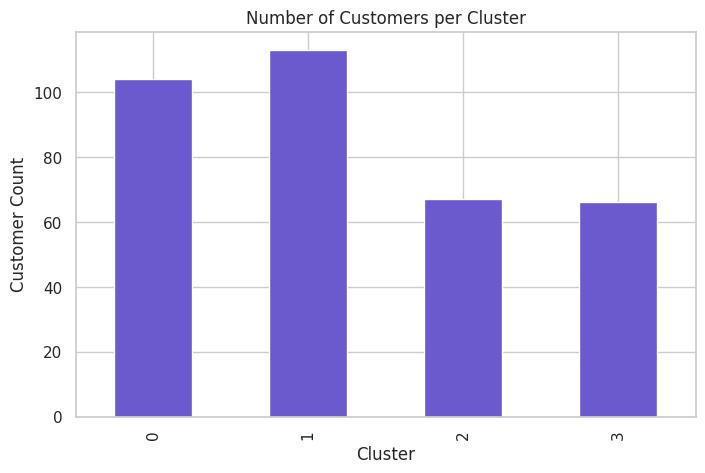

In [14]:
plt.figure(figsize=(8,5))
rfm['Cluster'].value_counts().sort_index().plot(kind='bar', color='slateblue')
plt.title("Number of Customers per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Customer Count")
plt.show()

## 12. Insights & Marketing Recommendations

*(Fill in based on your actual cluster profiles. Example structure:)*

1. **Loyal high-value customers** — Reward with a VIP loyalty program and early access to new products to maintain retention.

2. **At-risk / churned customers** — Launch a win-back email campaign with a time-limited discount to re-engage before they're lost entirely.

3. **New customers** — Set up an onboarding email sequence and a first-purchase follow-up offer to encourage a second purchase.

4. **Occasional shoppers** — Use targeted cross-sell/upsell recommendations based on past purchases to increase purchase frequency.